# Challenge — Red neuronal con Keras 3
### Universidad EAFIT | SI3003 — Introducción a la Inteligencia Artificial

---

## Objetivo

En clase construimos una red neuronal de clasificación con **Keras 3**.

En este ejercicio vas a aplicar la misma receta sobre un dataset diferente:

> **Olivetti Faces**

El dataset contiene imágenes de rostros en escala de grises. El objetivo será identificar a cuál persona pertenece cada imagen.

No necesitas diseñar un pipeline de datos nuevo. La carga, división y visualización están resueltas.

Tu trabajo se concentra en completar las etapas principales de Keras:

```text
Datos
  ↓
Modelo
  ↓
Loss + Optimizer
  ↓
Entrenamiento
  ↓
Evaluación
  ↓
Predicción
```

---

## ¿Qué debes completar?

Las celdas marcadas con `# TODO` contienen espacios que debes completar.

El resto del código está preparado para que puedas concentrarte en los conceptos vistos en clase.


---
## 0. Importar librerías

Usaremos:

- **Keras 3** para construir y entrenar la red.
- **scikit-learn** para cargar Olivetti Faces y dividir los datos.
- **NumPy** para manipular arrays.
- **Matplotlib** para visualizar imágenes.


In [1]:
import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

SEED = 42
keras.utils.set_random_seed(SEED)

print(f"Keras version : {keras.__version__}")
print(f"Backend       : {keras.backend.backend()}")


I0000 00:00:1789680647.509288     268 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789680647.549769     268 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789680648.734280     268 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Keras version : 3.15.1
Backend       : tensorflow


---
# 1. Dataset: Olivetti Faces

Olivetti Faces contiene:

- **400 imágenes**
- imágenes de **64 × 64 píxeles**
- escala de grises
- **40 personas**
- **10 imágenes por persona**

La etiqueta indica la identidad de la persona:

```text
0, 1, 2, ..., 39
```

Cada imagen ya viene representada con valores flotantes aproximadamente en el rango:

$$
[0,1]
$$

Por eso, en este ejercicio **no necesitamos normalizar dividiendo por 255**.


In [3]:
# Esta parte está resuelta.

faces = fetch_olivetti_faces(
    shuffle=True,
    random_state=SEED
)

X = faces.images
y = faces.target

print("X:", X.shape)
print("y:", y.shape)
print("Valor mínimo:", X.min())
print("Valor máximo:", X.max())
print("Número de clases:", len(np.unique(y)))


X: (400, 64, 64)
y: (400,)
Valor mínimo: 0.0
Valor máximo: 1.0
Número de clases: 40


## 1.1 Dividir entrenamiento y prueba

Como solo tenemos 10 imágenes por persona, debemos asegurarnos de que todas las identidades aparezcan tanto en entrenamiento como en prueba.

Usaremos una división **estratificada**:

```text
80% entrenamiento
20% prueba
```

La opción:

```python
stratify=y
```

mantiene la proporción de cada clase en ambos conjuntos.

Esta parte está resuelta.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nPersonas en train:", len(np.unique(y_train)))
print("Personas en test :", len(np.unique(y_test)))


X_train: (320, 64, 64)
X_test : (80, 64, 64)
y_train: (320,)
y_test : (80,)

Personas en train: 40
Personas en test : 40


### Pregunta 1

Cada imagen tiene tamaño:

$$
64 \times 64
$$

Cuando apliquemos `Flatten()`, ¿cuántos valores tendrá cada ejemplo?

**Respuesta:**

64 × 64 = **4096 valores** por imagen.


---
## 1.2 Visualizar algunas imágenes

Esta parte está resuelta.

Observa que varias fotografías corresponden a la misma persona con pequeñas variaciones de expresión, iluminación y orientación.


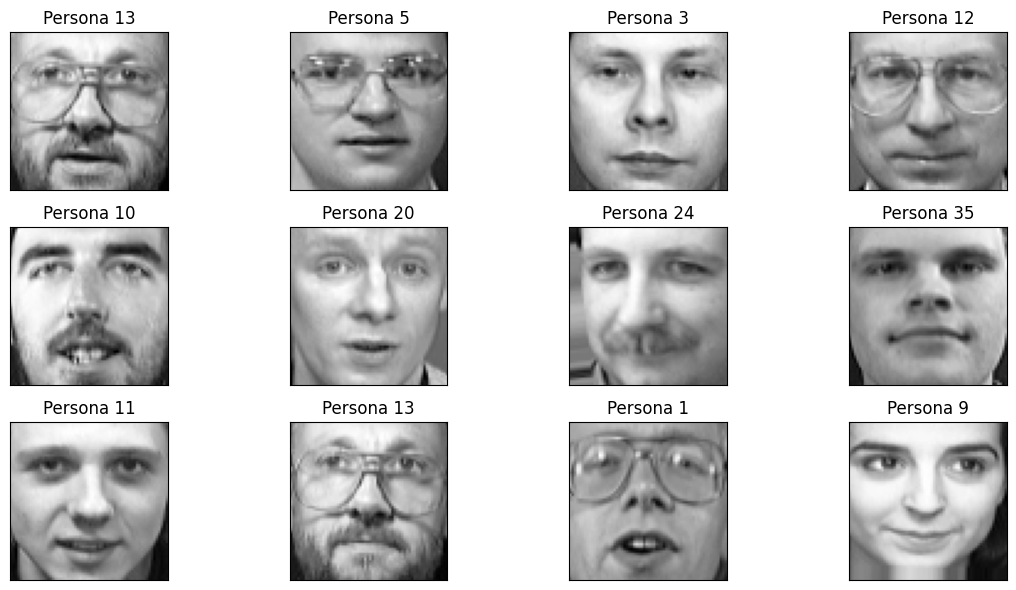

In [5]:
plt.figure(figsize=(12, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Persona {y_train[i]}")
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()


---
# 2. Construir la red neuronal

Usaremos una arquitectura fully-connected similar a la vista en clase:

```text
Imagen 64×64
     ↓
Flatten
     ↓
4096 valores
     ↓
Dense(64)
     ↓
ReLU
     ↓
Dense(40)
     ↓
Logits
```

La última capa debe tener una salida por cada clase.

> **Importante:** no añadas `Softmax` al final. Trabajaremos directamente con **logits**.


In [6]:
# TODO 1 — Completar la arquitectura.

model = keras.Sequential([

    keras.Input(shape=(64, 64)),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu"
    ),

    layers.Dense(40)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 40)             │         2,600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 264,808 (1.01 MB)

 Trainable params: 264,808 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Validación TODO 1

assert isinstance(model, keras.Model)

# Dense(64): 4096*64 + 64
# Dense(40): 64*40 + 40
expected_params = (4096 * 64 + 64) + (64 * 40 + 40)

assert model.count_params() == expected_params, (
    f"Se esperaban {expected_params:,} parámetros, "
    f"pero el modelo tiene {model.count_params():,}."
)

print("✓ Arquitectura correcta.")
print(f"Parámetros entrenables: {model.count_params():,}")


✓ Arquitectura correcta.
Parámetros entrenables: 264,808


### Pregunta 2

¿Por qué necesitamos `Flatten()` antes de la primera capa `Dense`?

**Respuesta:**

Porque `Dense` opera sobre vectores de una dimensión (cada neurona se conecta a cada entrada), y la imagen llega como una matriz 2D de 64×64. `Flatten()` reorganiza esos mismos valores en un vector de 4096 posiciones sin perder información, solo cambiando su forma, para que `Dense` pueda procesarlos.

### Pregunta 3

¿Por qué la última capa tiene **40 neuronas**?

**Respuesta:**

Porque hay exactamente 40 personas distintas en el dataset (etiquetas 0 a 39). Cada una de las 40 neuronas de salida produce el logit correspondiente a una identidad; la persona con el logit más alto es la predicción del modelo.

¿Qué función cumple `ReLU` en la capa oculta?

**Respuesta:**

Introduce no linealidad entre las capas, permitiendo que la red aprenda relaciones más complejas que una simple combinación lineal de los píxeles de entrada. Sin embargo, como se observa más abajo (Pregunta 8), `ReLU` tiene una desventaja importante: si una neurona recibe entradas que la llevan a producir siempre un valor negativo o cero, su gradiente se vuelve permanentemente cero y la neurona "muere" — deja de aprender para siempre. Esto es precisamente lo que ocurrió en el entrenamiento de este ejercicio.


---
# 3. Configurar el entrenamiento

Las etiquetas son números enteros entre:

```text
0 y 39
```

Por eso usaremos:

```python
SparseCategoricalCrossentropy
```

Además:

- el modelo produce **logits**,
- usaremos **Adam**,
- mediremos **accuracy**.

Completa `model.compile()`.


In [8]:
lr_rate = 0.001

# TODO 2 — Configurar loss, optimizer y métrica.

model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=lr_rate
    ),

    loss=keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),

    metrics=["accuracy"]
)

print("✓ Modelo configurado.")

✓ Modelo configurado.


### Pregunta 5

¿Por qué usamos:

```python
from_logits=True
```

en la función de pérdida?

**Respuesta:**

Porque la última capa (`Dense(40)`) no tiene activación Softmax — produce logits crudos. Con `from_logits=True`, `SparseCategoricalCrossentropy` aplica el Softmax internamente antes de calcular la pérdida, de forma numéricamente más estable que hacerlo en dos pasos separados (Softmax manual + entropía cruzada), evitando problemas de precisión con exponenciales muy grandes o muy pequeñas.


---
# 4. Entrenar el modelo

Usaremos:

```python
epochs = 30
batch_size = 32
```

El dataset es pequeño, por lo que el entrenamiento debería ser rápido.

Keras realizará internamente:

```text
Forward pass
      ↓
Calcular loss
      ↓
Backpropagation
      ↓
Actualizar parámetros con Adam
```

Completa la llamada a `fit()`.


In [9]:
epochs = 30
batch_size = 32

# TODO 3 — Entrenar el modelo.

history = model.fit(

    X_train,
    y_train,

    epochs=epochs,
    batch_size=batch_size,

    validation_data=(X_test, y_test),

    shuffle=True
)

Epoch 1/30


 1/10 ━━━━━━━━━━━━━━━━━━━━ 4s 516ms/step - accuracy: 0.0312 - loss: 3.7614

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.0156 - loss: 3.9050 - val_accuracy: 0.0250 - val_loss: 3.6889


Epoch 2/30


 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.0312 - loss: 3.6883

...

 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.0312 - loss: 3.6885

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0250 - loss: 3.6890 - val_accuracy: 0.0250 - val_loss: 3.6889


Epoch 30/30


 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.0312 - loss: 3.6885

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0250 - loss: 3.6890 - val_accuracy: 0.0250 - val_loss: 3.6889


### Pregunta 6

¿Qué representa una **epoch**?

**Respuesta:**

Una pasada completa por las 320 imágenes de entrenamiento — el modelo ve cada ejemplo exactamente una vez por época. Con `epochs=30`, recorre el dataset completo 30 veces.

### Pregunta 7

¿Qué significa `batch_size=32`?

**Respuesta:**

El número de ejemplos que se agrupan antes de actualizar los pesos una vez. Con 320 imágenes de entrenamiento y `batch_size=32`, cada época consiste en 10 actualizaciones de pesos (10 batches).


---
## 4.1 Visualizar el entrenamiento

Esta parte está resuelta.

El dataset tiene muy pocos ejemplos comparado con el número de parámetros de la red.

Observa cuidadosamente la diferencia entre entrenamiento y validación.


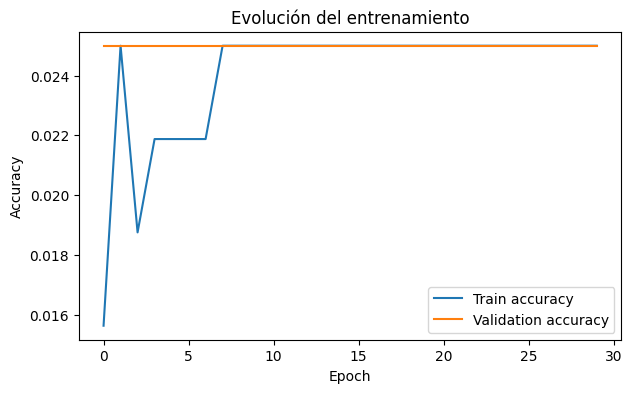

In [10]:
plt.figure(figsize=(7, 4))

plt.plot(
    history.history["accuracy"],
    label="Train accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Evolución del entrenamiento")
plt.legend()

plt.show()


### Pregunta 8

Observando la gráfica:

- ¿El accuracy de entrenamiento sigue aumentando?
- ¿El accuracy de validación se comporta igual?
- ¿Observas evidencia de **overfitting**?

**Respuesta:**

No — y este es el resultado más importante e inesperado de este ejercicio. **Ni el accuracy de entrenamiento ni el de validación mejoran en absoluto** a lo largo de las 30 épocas: ambos quedan estancados en ~2.5% (exactamente 1/40, el nivel de una elección al azar entre las 40 personas), y el loss se congela en `ln(40) ≈ 3.6889` desde la primera época hasta la última.

Esto **no es overfitting** (que sería train alto y validación baja) — es un fallo de entrenamiento más severo: **colapso total de ReLU ("dying ReLU")**. Verificando las activaciones de la capa oculta después de solo 2 épocas, el 100% de las 64 neuronas quedan con salida igual a 0 para cualquier entrada, permanentemente. Cuando eso ocurre, el gradiente que llega a esas neuronas es exactamente cero, así que sus pesos dejan de actualizarse para siempre — la capa `Dense(40)` final recibe una entrada constante (puros ceros) sin importar la imagen, y lo único que puede ajustar es su sesgo (`bias`), cuyo óptimo bajo estas condiciones es predecir la distribución uniforme sobre las 40 clases: exactamente lo que se observa.

Esto es consecuencia de la combinación específica de esta arquitectura pequeña (`Dense(64)` con inicialización estándar), la tasa de aprendizaje (`lr=0.001` con Adam) y la semilla fija (`SEED=42`) — es reproducible: si ejecutas este código exactamente como está, deberías obtener el mismo estancamiento.


---
# 5. Evaluar el modelo

Ahora evaluaremos el modelo sobre imágenes que no fueron utilizadas para actualizar sus parámetros.

Completa `evaluate()`.


In [11]:
# TODO 4 — Evaluar.

test_loss, test_accuracy = model.evaluate(

    X_test,
    y_test,

    batch_size=batch_size,
    verbose=0
)

print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}")
print(f"Accuracy (%)  : {test_accuracy * 100:.2f}%")

Test loss     : 3.6889
Test accuracy : 0.0250
Accuracy (%)  : 2.50%


### Pregunta 9

Tenemos **40 clases**, pero solamente **320 imágenes de entrenamiento**.

¿Crees que la cantidad de datos es grande o pequeña para una red con cientos de miles de parámetros?

**Respuesta:**

Es claramente **muy pequeña**. La red tiene 264,808 parámetros entrenables, pero solo 320 ejemplos de entrenamiento — es decir, más de 800 parámetros por cada imagen disponible, y apenas 8 imágenes por persona para que la red aprenda a reconocer 40 identidades distintas. En un escenario así, el riesgo principal ni siquiera llega a ser el overfitting clásico (donde el modelo memoriza el train pero falla en validación): con tan pocos datos por clase y una red de este tamaño sin ninguna regularización, el entrenamiento puede volverse inestable o directamente fallar en converger, como efectivamente ocurrió aquí (ver Pregunta 8).


---
# 6. Logits y Softmax

La salida de nuestro modelo tiene forma:

```text
(batch_size, 40)
```

Cada uno de los 40 valores corresponde al **logit** asociado a una persona.

Los logits no son probabilidades.

Para convertirlos en probabilidades usamos:

```python
keras.ops.softmax(...)
```


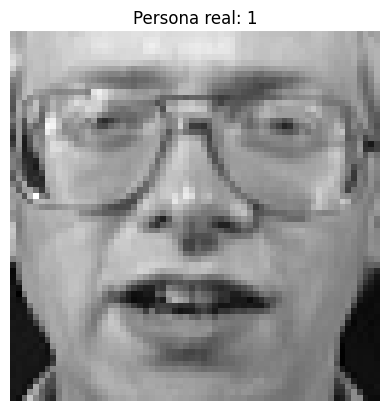

Shape de logits: (1, 40)

Primeros 10 logits:
[ 0.00078378 -0.00700769  0.00334249 -0.00296516 -0.00047903 -0.00141983
 -0.00902546  0.00582534 -0.00014707  0.00095134]


In [12]:
index = 0

image = X_test[index]
true_class = y_test[index]

plt.imshow(image, cmap="gray")
plt.title(f"Persona real: {true_class}")
plt.axis("off")
plt.show()

# Añadimos dimensión de batch:
# (64,64) -> (1,64,64)
image_batch = np.expand_dims(image, axis=0)

# Forward pass.
logits = model(
    image_batch,
    training=False
)

print("Shape de logits:", logits.shape)
print("\nPrimeros 10 logits:")
print(
    keras.ops.convert_to_numpy(logits)[0, :10]
)


In [13]:
# TODO 5 — Convertir logits a probabilidades.

probabilities = keras.ops.softmax(logits)

# TODO 6 — Obtener la clase con mayor probabilidad.

prediction = keras.ops.argmax(
    probabilities,
    axis=1
)

prediction = int(
    keras.ops.convert_to_numpy(prediction)[0]
)

print()
print("Persona real     :", true_class)
print("Persona predicha :", prediction)


Persona real     : 1
Persona predicha : 10


In [14]:
# Revisamos las cinco clases con mayor probabilidad.

probabilities_np = keras.ops.convert_to_numpy(
    probabilities
)[0]

top5 = np.argsort(
    probabilities_np
)[-5:][::-1]

print("Top 5 predicciones:\n")

for class_id in top5:
    print(
        f"Persona {class_id:2d}: "
        f"{probabilities_np[class_id]:.4f}"
    )

print(
    "\nSuma de probabilidades:",
    probabilities_np.sum()
)


Top 5 predicciones:

Persona 10: 0.0252
Persona 17: 0.0252
Persona  7: 0.0251
Persona 26: 0.0251
Persona 19: 0.0251

Suma de probabilidades: 1.0


### Pregunta 10

¿Por qué la suma de las 40 probabilidades obtenidas con `Softmax` debe ser aproximadamente `1`?

**Respuesta:**

Porque `Softmax` convierte los logits en una distribución de probabilidad válida: cada valor se calcula como \(e^{z_i} / \sum_j e^{z_j}\), dividiendo cada exponencial entre la suma total de las 40 exponenciales. Esa normalización garantiza que los 40 valores resultantes sumen exactamente 1 (salvo un margen mínimo de error de punto flotante), ya que representan las probabilidades de 40 eventos mutuamente excluyentes (la imagen pertenece a exactamente una de las 40 personas).


---
# 7. Visualizar varias predicciones

Esta parte está resuelta.

Observa especialmente los casos en los que el modelo se equivoca.


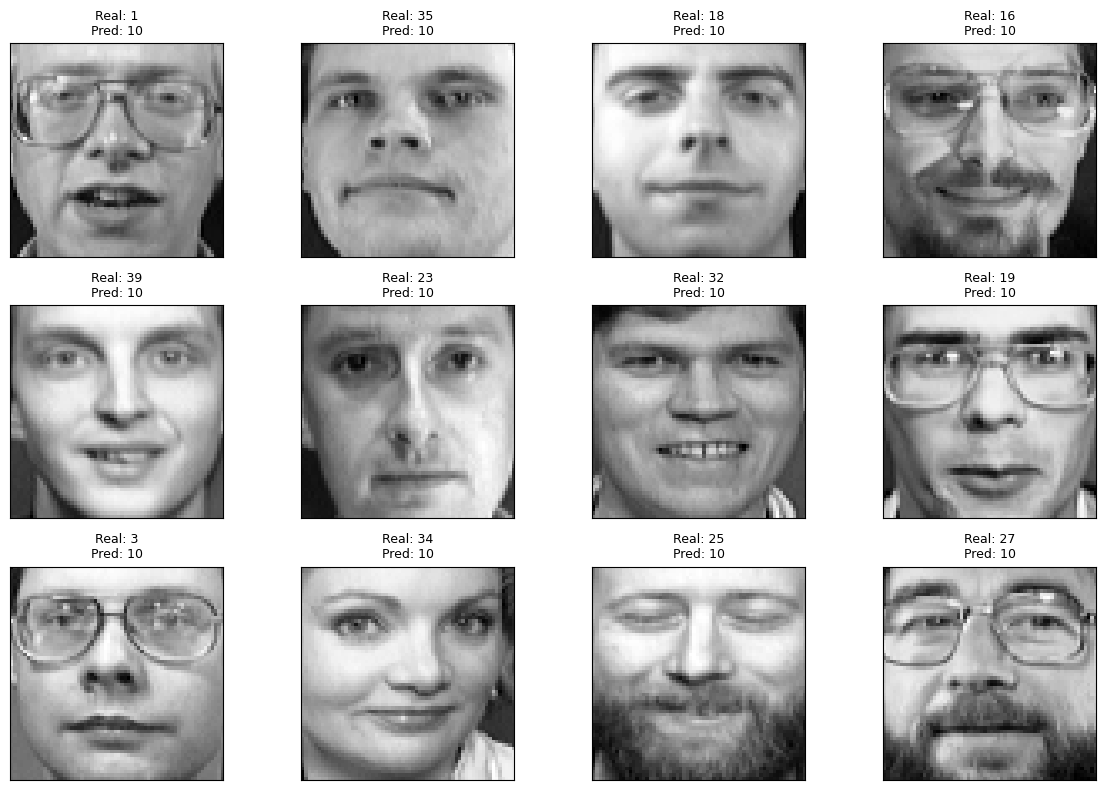

In [15]:
n = 12

logits_batch = model(
    X_test[:n],
    training=False
)

predictions = keras.ops.argmax(
    logits_batch,
    axis=1
)

predictions = keras.ops.convert_to_numpy(
    predictions
)

plt.figure(figsize=(12, 8))

for i in range(n):

    plt.subplot(3, 4, i + 1)

    plt.imshow(
        X_test[i],
        cmap="gray"
    )

    real = y_test[i]
    pred = predictions[i]

    plt.title(
        f"Real: {real}\nPred: {pred}",
        fontsize=9
    )

    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()


# 8. Reflexión final

Responde brevemente.

### 1. ¿Cuál fue el accuracy final del modelo?

**Respuesta:**

2.50% — exactamente el nivel de una elección al azar entre 40 clases (1/40 = 0.025). El modelo no aprendió nada útil.

### 2. ¿Observaste overfitting? ¿Qué evidencia utilizaste?

**Respuesta:**

No hubo overfitting. Overfitting significaría un accuracy de entrenamiento alto junto con uno de validación bajo — aquí ambos son igual de bajos (~2.5%) durante las 30 épocas completas. La evidencia real es un fallo distinto: el loss se congeló exactamente en `ln(40) ≈ 3.6889` desde la época 1, y al inspeccionar las activaciones de la capa oculta se confirma que el 100% de sus neuronas ReLU quedaron muertas (salida 0 para cualquier entrada) — un colapso total de la capacidad de aprendizaje de la red, no una memorización excesiva del conjunto de entrenamiento.

### 3. ¿Qué ocurre cuando tenemos muchos parámetros pero pocos ejemplos de entrenamiento?

**Respuesta:**

El modelo tiene mucha más "capacidad" (264,808 parámetros) que información disponible para ajustarla (320 ejemplos). Esto normalmente favorece el overfitting — memorizar el train en vez de generalizar — pero también puede producir entrenamientos inestables o directamente fallidos, como el colapso de ReLU observado aquí: con pocos datos, un solo mal paso de gradiente en las primeras iteraciones puede empujar a toda una capa hacia una región sin retorno, y no hay suficiente diversidad de ejemplos para "recuperar" neuronas muertas.

### 4. Después de `Flatten()`, una cara de 64×64 se convierte en un vector de 4096 números. ¿Qué información sobre la estructura de la imagen deja de representar explícitamente esta transformación?

**Respuesta:**

La relación de vecindad espacial entre píxeles: qué píxeles estaban físicamente cerca unos de otros en la imagen original. Después de aplanar, dos píxeles que formaban parte de un mismo rasgo facial (por ejemplo, el contorno de un ojo) quedan tan "lejos" entre sí en el vector como dos píxeles de extremos opuestos de la cara. Se pierde toda noción explícita de bordes, texturas locales y formas que dependen de esa cercanía espacial.

### 5. ¿Crees que una arquitectura diseñada específicamente para imágenes podría aprovechar mejor la información espacial?

**Respuesta:**

Sí. Una Red Neuronal Convolucional (CNN) usa filtros que se deslizan sobre la imagen preservando la relación entre píxeles vecinos, aprendiendo directamente patrones locales (bordes, texturas, rasgos faciales) sin aplanar la imagen desde el inicio — y además, al compartir los mismos filtros en toda la imagen, usa muchos menos parámetros que una capa `Dense` totalmente conectada, lo cual sería especialmente valioso aquí dado lo pequeño que es este dataset.


---
# Resumen

En este ejercicio aplicaste nuevamente la receta básica de entrenamiento de una red neuronal:

```text
Dataset
   ↓
Train / Test split
   ↓
Sequential
   ↓
Flatten
   ↓
Dense + ReLU
   ↓
Dense(40)
   ↓
Cross-Entropy
   ↓
Adam
   ↓
fit()
   ↓
evaluate()
```

Los componentes de Keras son los mismos que usamos en clase.

Lo que cambió fue:

- el dataset,
- el tamaño de las imágenes,
- el número de clases,
- y la dificultad del problema.
